# A Basic G10 FX Carry Trade

**What is a carry trade?** You *borrow* in a low-interest-rate currency and *invest* in a high-interest-rate one. You pocket the interest-rate differential (the "carry") every day. The risk: the high-yield currency can depreciate and wipe out that yield. The [uncovered interest parity](https://en.wikipedia.org/wiki/Interest_rate_parity) puzzle is that, historically, it often *doesn't* depreciate enough — so carry has earned a positive premium.

**How we implement it here (the classic G10 long/short book):**
1. Each month, rank the 9 floating G10 currencies by their forward-implied carry (≈ rate differential vs USD).
2. Go **long** the 3 highest-yielders (e.g. AUD, NZD), **short** the 3 lowest-yielders (e.g. JPY, CHF), equally weighted, dollar-neutral.
3. Hold for the month, rebalance, repeat. Measure the gross return.

The engine lives in [`carry_utils.py`](carry_utils.py) — a trimmed version of the `cesare/fx_utils.py` research library. Run this notebook top-to-bottom with the working directory set to `oleg/`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import carry_utils as cu

plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (10, 4.5),
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Load the data

We read the shared, git-tracked Bloomberg snapshot at the repo root (`data/raw/g10_fx_spot_forward_wide.parquet`) — daily G10 spot rates plus forward points, 2007 → 2026. `load_wide` selects the `PX_LAST` field and cleans up the Bloomberg ticker names.

In [2]:
g10 = cu.load_wide("g10_fx_spot_forward")
print(f"{g10.shape[0]:,} daily rows, {g10.index[0].date()} → {g10.index[-1].date()}")

# spot + the 1M forward-point tickers we use for the 9 tradable currencies
cols = [c for c in g10.columns if c in cu.G10_FLOAT or c[:-2] in cu.G10_FLOAT and c.endswith("1M")]
g10[sorted(cols)].tail(3)

5,087 daily rows, 2007-01-01 → 2026-06-30


,AUD,AUD1M,CAD,CAD1M,CHF,CHF1M,EUR,EUR1M,GBP,GBP1M,JPY,JPY1M,NOK,NOK1M,NZD,NZD1M,SEK,SEK1M
date,,,,,,,,,,,,,,,,,,
2026-06-26,0.6896,-4.2000,1.4195,-18.1100,0.8097,-27.4700,1.1384,14.4800,1.3200,-0.3800,161.7400,-40.0700,9.9320,40.0800,0.5641,6.0800,9.7370,-162.1100
2026-06-29,0.6887,-4.4500,1.4211,-18.8200,0.8077,-29.0200,1.1422,15.3400,1.3258,-0.4100,161.9400,-42.2100,9.9287,43.2100,0.5651,6.2200,9.7120,-171.9800
2026-06-30,0.6919,-4.0200,1.4196,-20.2300,0.8084,-28.1900,1.1422,14.8400,1.3262,-0.3000,162.5500,-40.8500,9.9024,42.7500,0.5678,5.9300,9.7015,-167.5200


## 2. Build the currency panels

Three steps turn raw quotes into tradable return series:
- **`spots_usd_per_fx`** — re-express every spot as USD-per-FX, so "up" always means the foreign currency *appreciated*.
- **`carry_panel`** — the signal: annualised `ln(spot / forward)`. Under covered interest parity this equals the currency's interest-rate differential vs USD.
- **`excess_returns`** — the daily payoff of holding each currency: spot log-return **+** yesterday's carry accrued over one day.

In [3]:
spots = cu.spots_usd_per_fx(g10)
carry = cu.carry_panel(g10, tenor="1M")
xret = cu.excess_returns(spots, carry)

print("currencies:", list(xret.columns))
carry.tail(3)

currencies: ['AUD', 'CAD', 'CHF', 'EUR', 'GBP', 'JPY', 'NOK', 'NZD', 'SEK']


,AUD,CAD,CHF,EUR,GBP,JPY,NOK,NZD,SEK
date,,,,,,,,,
2026-06-26,0.0073,-0.0153,-0.0408,-0.0153,0.0003,-0.0298,0.0048,-0.0129,-0.0200
2026-06-29,0.0078,-0.0159,-0.0432,-0.0161,0.0004,-0.0313,0.0052,-0.0132,-0.0213
2026-06-30,0.0070,-0.0171,-0.0419,-0.0156,0.0003,-0.0302,0.0052,-0.0125,-0.0207


## 3. Which currencies are high- vs low-yield?

The carry signal is what decides the long and short legs. Averaging each currency's annualised carry over the whole sample shows the textbook split: commodity/high-rate currencies (AUD, NZD, NOK) sit on the long side; funding currencies (JPY, CHF) on the short side.

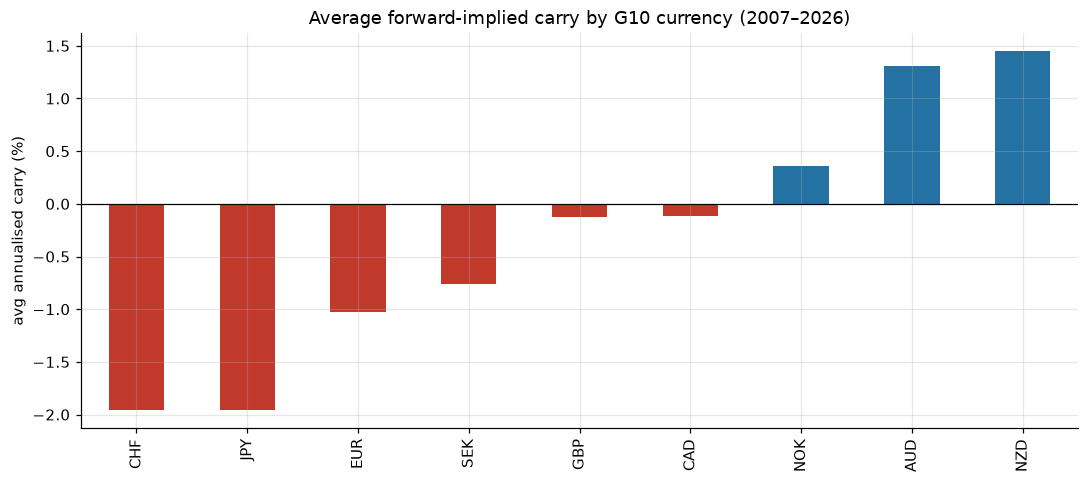

In [4]:
avg_carry = (carry.mean() * 100).sort_values()
colors = ["#c0392b" if v < 0 else "#2471a3" for v in avg_carry]

ax = avg_carry.plot.bar(color=colors)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("avg annualised carry (%)")
ax.set_title("Average forward-implied carry by G10 currency (2007–2026)")
plt.tight_layout()
plt.show()

## 4. Run the backtest

`carry_portfolio` does the monthly rank-and-sort into terciles (long top 3, short bottom 3, equal-weight), forward-fills the weights to daily and **shifts them one day** so we only trade on information already known. `portfolio_returns` then computes the daily book return as the weighted sum of currency excess returns.

In [5]:
weights = cu.carry_portfolio(carry, xret, n_buckets=3)
ret = cu.portfolio_returns(weights, xret, name="G10_carry")

# sanity check: dollar-neutral, gross ~2 on live days
live = weights.dropna(how="all").iloc[-1]
print("latest weights:")
print(live[live != 0].round(3).to_string())
print(f"\nnet exposure: {live.sum():+.3f}   gross exposure: {live.abs().sum():.3f}")

latest weights:
AUD    0.3330
CHF   -0.3330
GBP    0.3330
JPY   -0.3330
NOK    0.3330
SEK   -0.3330

net exposure: +0.000   gross exposure: 2.000


## 5. The equity curve

Cumulative gross PnL of the strategy (cumulative sum of daily log excess returns — the cesare convention). Expect a positive but *choppy* drift, with a sharp drawdown in the 2008 crisis when carry currencies crashed together.

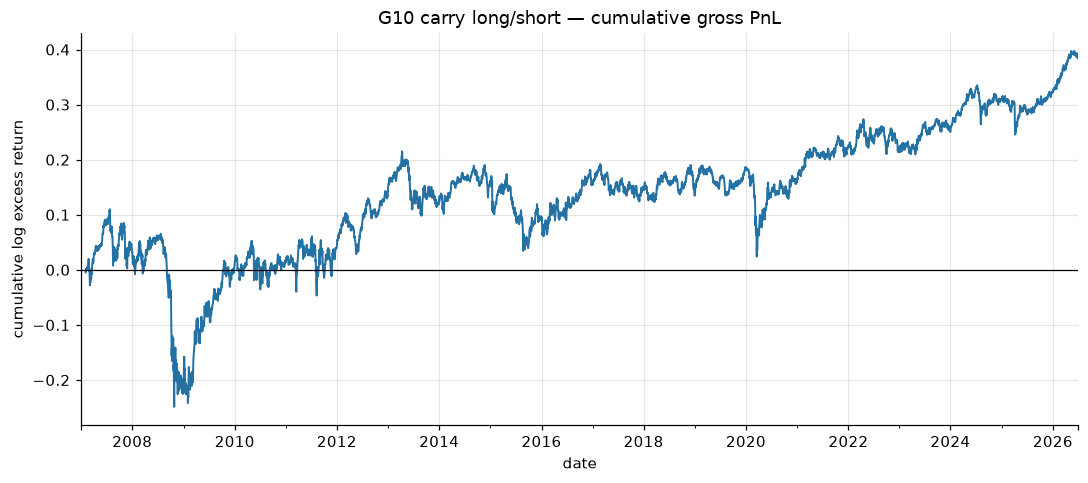

In [6]:
ax = ret.cumsum().plot(color="#2471a3", lw=1.3)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("cumulative log excess return")
ax.set_title("G10 carry long/short — cumulative gross PnL")
plt.tight_layout()
plt.show()

## 6. Performance summary

In [7]:
cu.summary_stats(ret.to_frame())

,start,end,n_days,ann_return,ann_vol,sharpe,max_drawdown,hit_rate
G10_carry,2007-02-01,2026-06-30,5064,0.0193,0.0916,0.2109,-0.3136,0.5361


## Takeaways

- The G10 carry trade is a **real but modest and noisy** premium — a low single-digit Sharpe, punctuated by crash risk (2008). That fragility is exactly what the academic "carry = compensation for crash risk" story predicts.
- This is deliberately the *simplest* version: equal-weight, gross-only, no risk management. The `cesare/` project shows the natural next steps, each of which we can bolt on here:
  1. **Add EM currencies** — the carry premium is far larger in EM than G10 (cesare's headline finding).
  2. **Volatility targeting** — scale the book to a constant 10% annualised vol for a cleaner risk profile.
  3. **Transaction costs** — charge the bid/ask forward spread to get net-of-cost returns.
  4. **Inverse-vol weighting** within each leg instead of equal weight.